 
#  <div align="center"> VISUALISASI UAS DWH </div>
 

---

In [17]:
pip install openpyxl

Note: you may need to restart the kernel to use updated packages.


In [18]:
pip install xlrd

   ---------------------------------------- 0.0/96.5 kB ? eta -:--:--
   ---------------------------------------- 0.0/96.5 kB ? eta -:--:--
   ---------------------------------------- 0.0/96.5 kB ? eta -:--:--
   ---- ----------------------------------- 10.2/96.5 kB ? eta -:--:--
   ---------------- ----------------------- 41.0/96.5 kB 653.6 kB/s eta 0:00:01
   ---------------- ----------------------- 41.0/96.5 kB 653.6 kB/s eta 0:00:01
   ---------------- ----------------------- 41.0/96.5 kB 653.6 kB/s eta 0:00:01
   --------------------------------- ------ 81.9/96.5 kB 353.1 kB/s eta 0:00:01
   --------------------------------- ------ 81.9/96.5 kB 353.1 kB/s eta 0:00:01
   ---------------------------------------- 96.5/96.5 kB 290.5 kB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


In [5]:
import pandas as pd
my_data = pd.read_excel('dataset2.xls')
print(my_data.head())

   customer_id customer_name state_code  FK_customer  product_id product_name  \
0          501      John Doe         CA            1        2001   Smartphone   
1          502    Jane Smith         NY            2        2002       Laptop   
2          503   Alice Brown         TX            3        2003   Headphones   
3          504     Bob White         FL            4        2004   Smartwatch   
4          505   Chris Green         IL            5        2005       Tablet   

      category   brand  cost  FK_custumerproduct  ...  discount  \
0  Electronics  BrandA   200                   1  ...        10   
1  Electronics  BrandB   800                   2  ...        50   
2  Accessories  BrandC    50                   3  ...         5   
3    Wearables  BrandD   150                   4  ...        20   
4  Electronics  BrandE   300                   5  ...        30   

                  promotion_date total_cost total_sales  quantity sales_id  \
0  2024/01/01 00:00:00.000000000

In [9]:
my_data.info()
my_data.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 24 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   customer_id         100 non-null    int64 
 1   customer_name       100 non-null    object
 2   state_code          100 non-null    object
 3   FK_customer         100 non-null    int64 
 4   product_id          100 non-null    int64 
 5   product_name        100 non-null    object
 6   category            100 non-null    object
 7   brand               100 non-null    object
 8   cost                100 non-null    int64 
 9   FK_custumerproduct  100 non-null    int64 
 10  FK_produk           100 non-null    int64 
 11  order_id            100 non-null    int64 
 12  delivery_date       100 non-null    object
 13  status              100 non-null    object
 14  discount            100 non-null    int64 
 15  promotion_date      100 non-null    object
 16  total_cost          100 non

,customer_id,customer_name,state_code,FK_customer,product_id,product_name,category,brand,cost,FK_custumerproduct,...,discount,promotion_date,total_cost,total_sales,quantity,sales_id,FK_TrasactionOrder,promotion_date_1,FK_prosestransaksi,date_time
0,501,John Doe,CA,1,2001,Smartphone,Electronics,BrandA,200,1,...,10,2024/01/01 00:00:00.000000000,200,250,1,301,1,2024/01/01 00:00:00.000000000,1,2024/01/12 16:43:29.000000000
1,502,Jane Smith,NY,2,2002,Laptop,Electronics,BrandB,800,2,...,50,2024/01/05 00:00:00.000000000,800,950,1,302,2,2024/01/05 00:00:00.000000000,2,2024/01/11 07:28:19.000000000
2,503,Alice Brown,TX,3,2003,Headphones,Accessories,BrandC,50,3,...,5,2024/01/08 00:00:00.000000000,100,140,2,303,3,2024/01/08 00:00:00.000000000,3,2024/01/14 05:22:26.000000000
3,504,Bob White,FL,4,2004,Smartwatch,Wearables,BrandD,150,4,...,20,2024/01/10 00:00:00.000000000,150,180,1,304,4,2024/01/10 00:00:00.000000000,4,2024/01/11 13:17:55.000000000
4,505,Chris Green,IL,5,2005,Tablet,Electronics,BrandE,300,5,...,30,2024/01/15 00:00:00.000000000,300,350,1,305,5,2024/01/15 00:00:00.000000000,5,2024/01/11 07:31:00.000000000


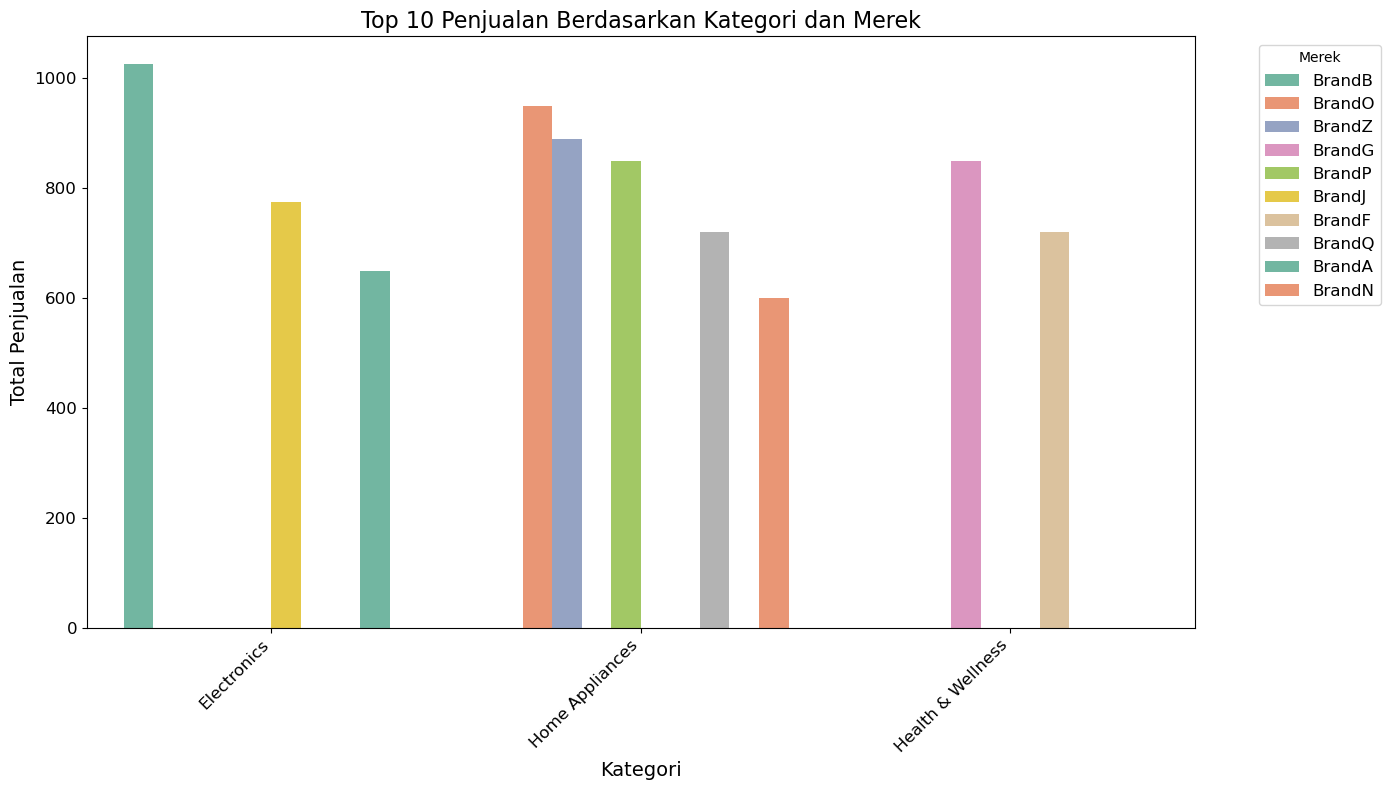

In [72]:
import matplotlib.pyplot as plt
import seaborn as sns

sales_by_category_brand = my_data.groupby(['category', 'brand'])['total_sales'].sum().reset_index()

top_sales_by_category_brand = sales_by_category_brand.sort_values(by='total_sales', ascending=False).head(10)

plt.figure(figsize=(14, 8))
sns.barplot(data=top_sales_by_category_brand, x='category', y='total_sales', hue='brand', palette='Set2')

plt.title('Top 10 Penjualan Berdasarkan Kategori dan Merek', fontsize=16)
plt.xlabel('Kategori', fontsize=14)
plt.ylabel('Total Penjualan', fontsize=14)
plt.xticks(rotation=45, ha='right', fontsize=12)
plt.yticks(fontsize=12)

plt.legend(title='Merek', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=12)

plt.tight_layout()
plt.show()


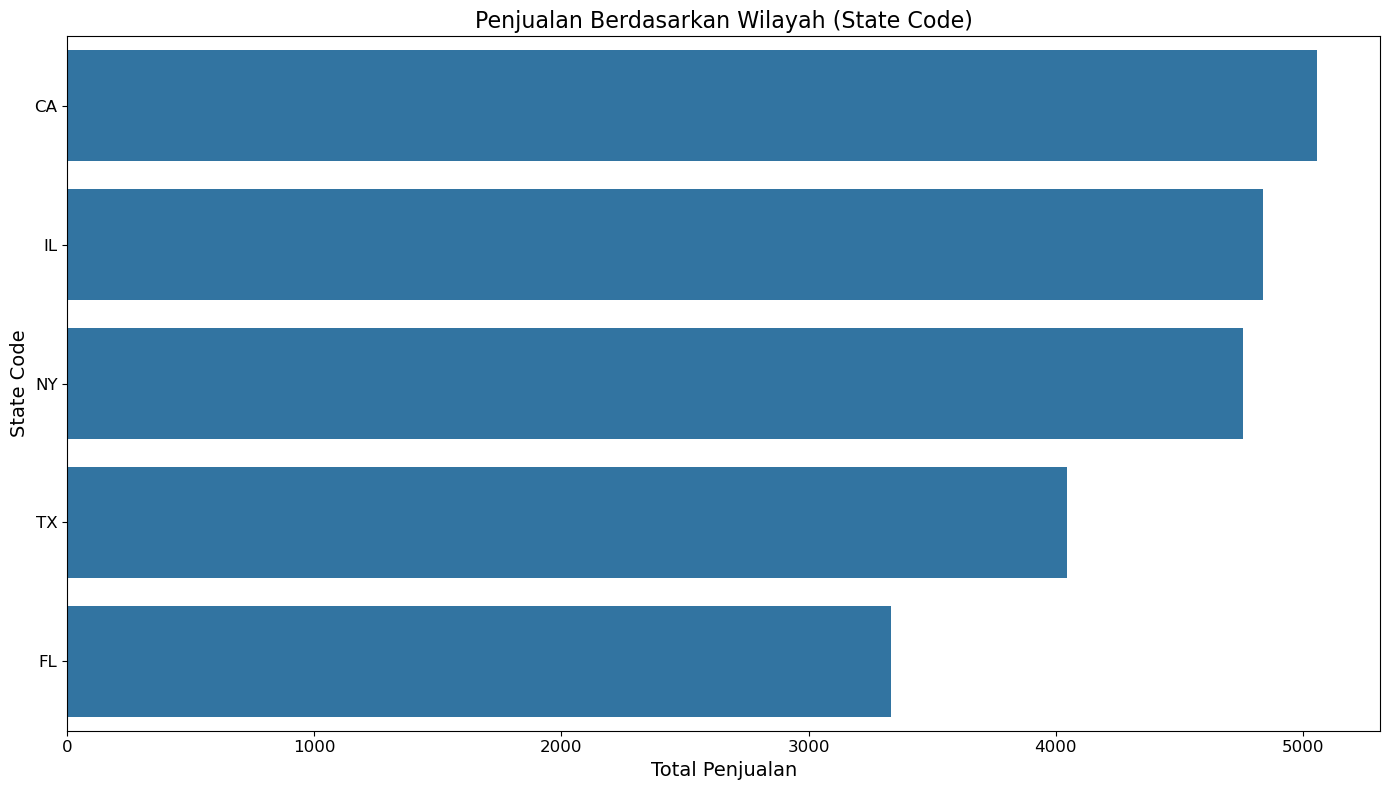

In [54]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

sales_by_state = my_data.groupby('state_code')['total_sales'].sum().reset_index()

if 'IL' not in sales_by_state['state_code'].values:
    # Menambahkan baris baru menggunakan pd.concat
    sales_by_state = pd.concat([sales_by_state, pd.DataFrame({'state_code': ['IL'], 'total_sales': [0]})], ignore_index=True)

state_order = ['CA', 'IL', 'NY', 'TX', 'FL']

plt.figure(figsize=(14, 8))

sns.barplot(data=sales_by_state, x='total_sales', y='state_code', palette=['#1f77b4']*len(state_order), order=state_order, hue='state_code', legend=False)

plt.title('Penjualan Berdasarkan Wilayah (State Code)', fontsize=16)
plt.xlabel('Total Penjualan', fontsize=14)
plt.ylabel('State Code', fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

 
plt.tight_layout()
plt.show()




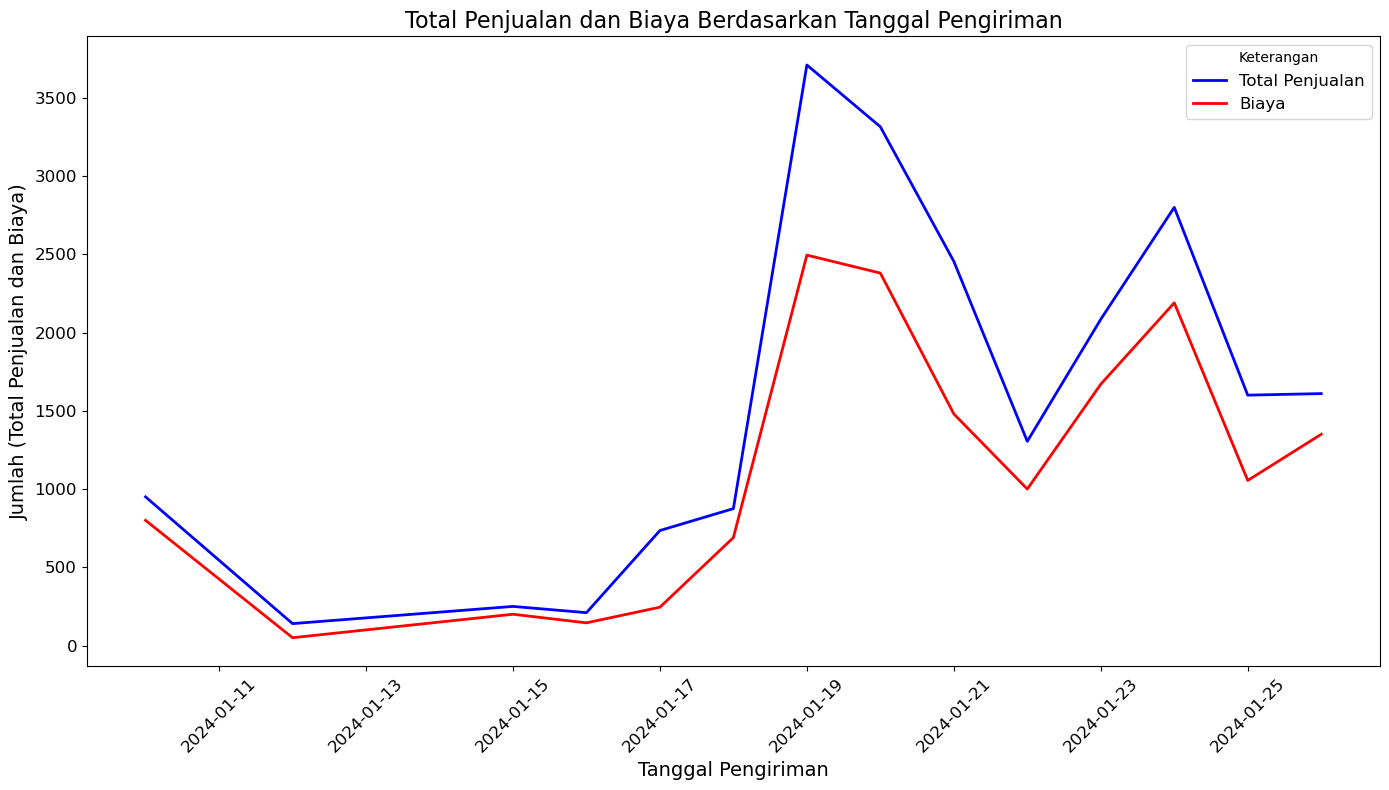

In [60]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Pastikan kolom 'delivery_date' adalah tipe datetime
my_data['delivery_date'] = pd.to_datetime(my_data['delivery_date'])

# Agregasi data: menghitung total penjualan dan biaya berdasarkan tanggal pengiriman
sales_cost_by_date = my_data.groupby('delivery_date')[['total_sales', 'cost']].sum().reset_index()

# Visualisasi data menggunakan seaborn (lineplot)
plt.figure(figsize=(14, 8))

# Membuat lineplot untuk total penjualan dan biaya berdasarkan tanggal pengiriman
sns.lineplot(data=sales_cost_by_date, x='delivery_date', y='total_sales', label='Total Penjualan', color='blue', linewidth=2)
sns.lineplot(data=sales_cost_by_date, x='delivery_date', y='cost', label='Biaya', color='red', linewidth=2)

# Menambahkan judul dan label
plt.title('Total Penjualan dan Biaya Berdasarkan Tanggal Pengiriman', fontsize=16)
plt.xlabel('Tanggal Pengiriman', fontsize=14)
plt.ylabel('Jumlah (Total Penjualan dan Biaya)', fontsize=14)
plt.xticks(rotation=45, fontsize=12)
plt.yticks(fontsize=12)
plt.legend(title='Keterangan', fontsize=12)

# Mengatur layout agar tidak terpotong
plt.tight_layout()

# Menampilkan grafik
plt.show()

C:\Users\wince\AppData\Local\Temp\ipykernel_19608\3847837126.py:9: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




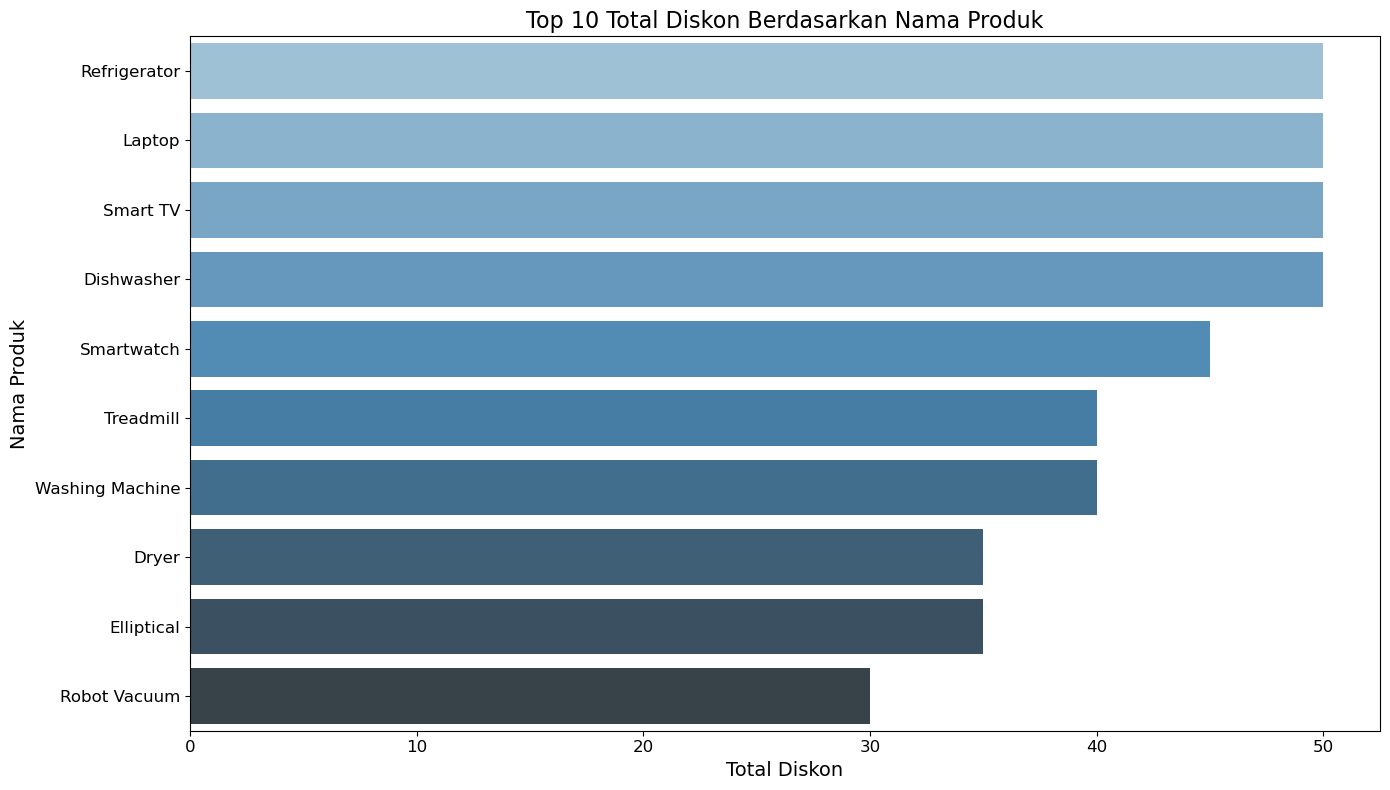

In [86]:
import matplotlib.pyplot as plt
import seaborn as sns

discount_by_product = my_data.groupby('product_name')['discount'].sum().reset_index()

top_discount_by_product = discount_by_product.sort_values(by='discount', ascending=False).head(10)

plt.figure(figsize=(14, 8))
sns.barplot(data=top_discount_by_product, x='discount', y='product_name', palette='Blues_d')

plt.title('Top 10 Total Diskon Berdasarkan Nama Produk', fontsize=16)
plt.xlabel('Total Diskon', fontsize=14)
plt.ylabel('Nama Produk', fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

plt.tight_layout()

plt.show()

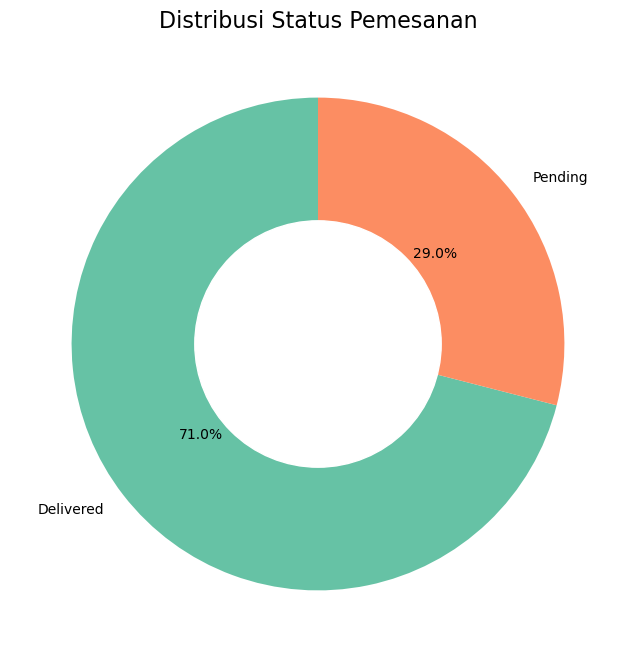

In [88]:
import matplotlib.pyplot as plt

status_counts = my_data['status'].value_counts()

plt.figure(figsize=(8, 8))
plt.pie(status_counts, labels=status_counts.index, autopct='%1.1f%%', startangle=90, colors=sns.color_palette('Set2', len(status_counts)))
plt.gca().add_artist(plt.Circle((0, 0), 0.5, color='white'))

plt.title('Distribusi Status Pemesanan', fontsize=16)

plt.show()

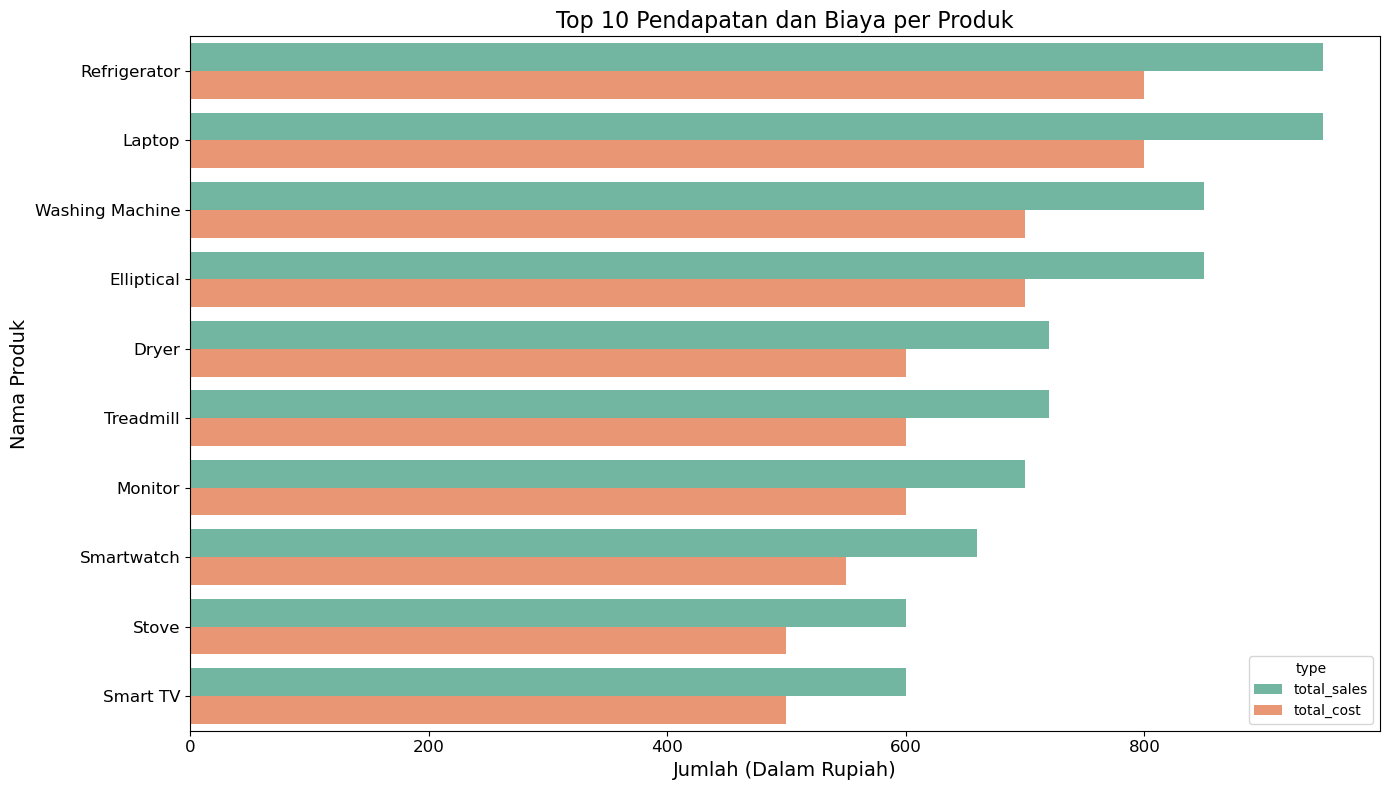

In [96]:
import matplotlib.pyplot as plt
import seaborn as sns

sales_and_cost_by_product = my_data.groupby('product_name')[['total_sales', 'total_cost']].sum().reset_index()
top_sales_and_cost_by_product = sales_and_cost_by_product.sort_values(by='total_sales', ascending=False).head(10)
top_sales_and_cost_by_product = pd.melt(top_sales_and_cost_by_product, id_vars=['product_name'], value_vars=['total_sales', 'total_cost'], 
                                        var_name='type', value_name='amount')

plt.figure(figsize=(14, 8))
sns.barplot(data=top_sales_and_cost_by_product, y='product_name', x='amount', hue='type', palette='Set2')

plt.title('Top 10 Pendapatan dan Biaya per Produk', fontsize=16)
plt.xlabel('Jumlah (Dalam Rupiah)', fontsize=14)
plt.ylabel('Nama Produk', fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

plt.tight_layout()
plt.show()

C:\Users\wince\AppData\Local\Temp\ipykernel_19608\1989408826.py:8: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




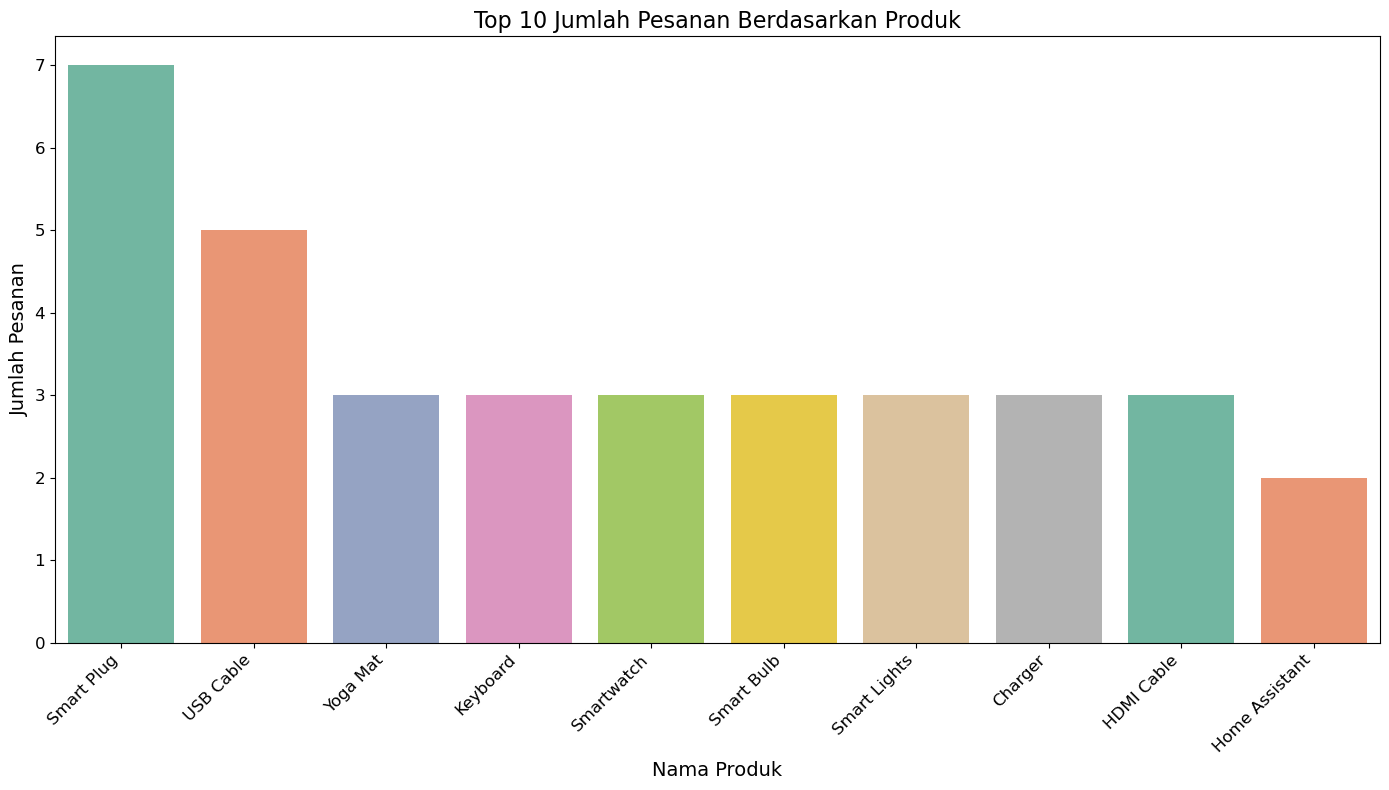

In [100]:
import matplotlib.pyplot as plt
import seaborn as sns

order_by_product = my_data.groupby('product_name')['quantity'].sum().reset_index()
top_order_by_product = order_by_product.sort_values(by='quantity', ascending=False).head(10)

plt.figure(figsize=(14, 8))
sns.barplot(data=top_order_by_product, x='product_name', y='quantity', palette='Set2')

plt.title('Top 10 Jumlah Pesanan Berdasarkan Produk', fontsize=16)
plt.xlabel('Nama Produk', fontsize=14)
plt.ylabel('Jumlah Pesanan', fontsize=14)
plt.xticks(rotation=45, ha='right', fontsize=12)
plt.yticks(fontsize=12)

plt.tight_layout()
plt.show()

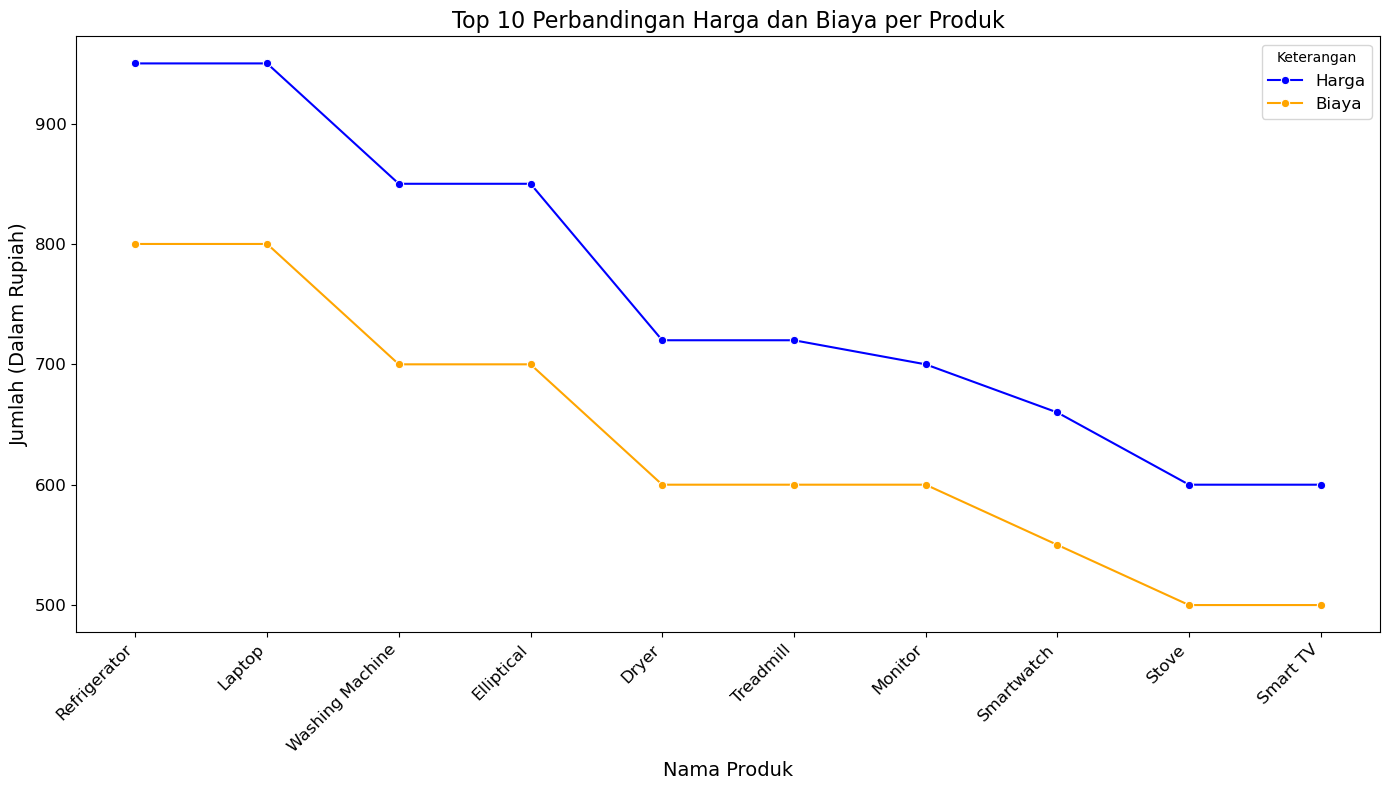

In [104]:
import matplotlib.pyplot as plt
import seaborn as sns

price_and_cost_by_product = my_data.groupby('product_name')[['total_sales', 'total_cost']].sum().reset_index()
top_price_and_cost_by_product = price_and_cost_by_product.sort_values(by='total_sales', ascending=False).head(10)

plt.figure(figsize=(14, 8))
sns.lineplot(data=top_price_and_cost_by_product, x='product_name', y='total_sales', marker='o', label='Harga', color='blue')
sns.lineplot(data=top_price_and_cost_by_product, x='product_name', y='total_cost', marker='o', label='Biaya', color='orange')

plt.title('Top 10 Perbandingan Harga dan Biaya per Produk', fontsize=16)
plt.xlabel('Nama Produk', fontsize=14)
plt.ylabel('Jumlah (Dalam Rupiah)', fontsize=14)
plt.xticks(rotation=45, ha='right', fontsize=12)
plt.yticks(fontsize=12)
plt.legend(title='Keterangan', fontsize=12)

plt.tight_layout()
plt.show()

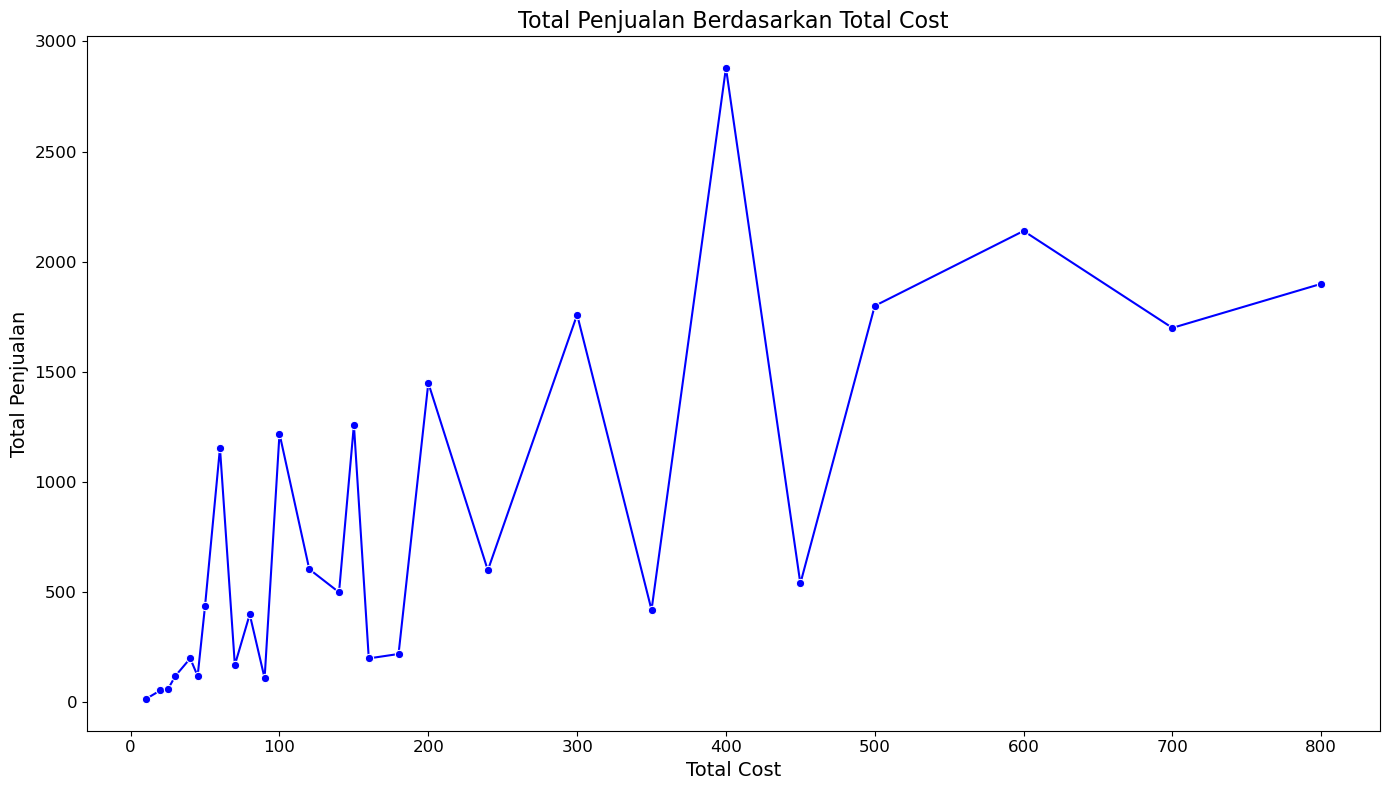

In [106]:
import matplotlib.pyplot as plt
import seaborn as sns

sales_and_cost = my_data.groupby('total_cost')['total_sales'].sum().reset_index()

plt.figure(figsize=(14, 8))
sns.lineplot(data=sales_and_cost, x='total_cost', y='total_sales', marker='o', color='blue')

plt.title('Total Penjualan Berdasarkan Total Cost', fontsize=16)
plt.xlabel('Total Cost', fontsize=14)
plt.ylabel('Total Penjualan', fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

plt.tight_layout()
plt.show()

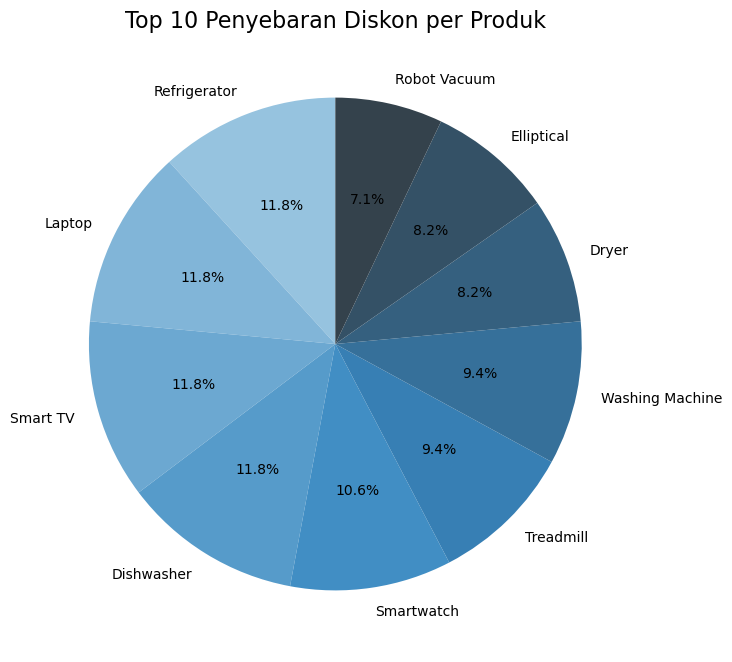

In [112]:
import matplotlib.pyplot as plt
import seaborn as sns

discount_by_product = my_data.groupby('product_name')['discount'].sum().reset_index()
top_discount_by_product = discount_by_product.sort_values(by='discount', ascending=False).head(10)

plt.figure(figsize=(8, 8))
plt.pie(top_discount_by_product['discount'], labels=top_discount_by_product['product_name'], autopct='%1.1f%%', startangle=90, colors=sns.color_palette('Blues_d', len(top_discount_by_product)))

plt.title('Top 10 Penyebaran Diskon per Produk', fontsize=16)

plt.show()

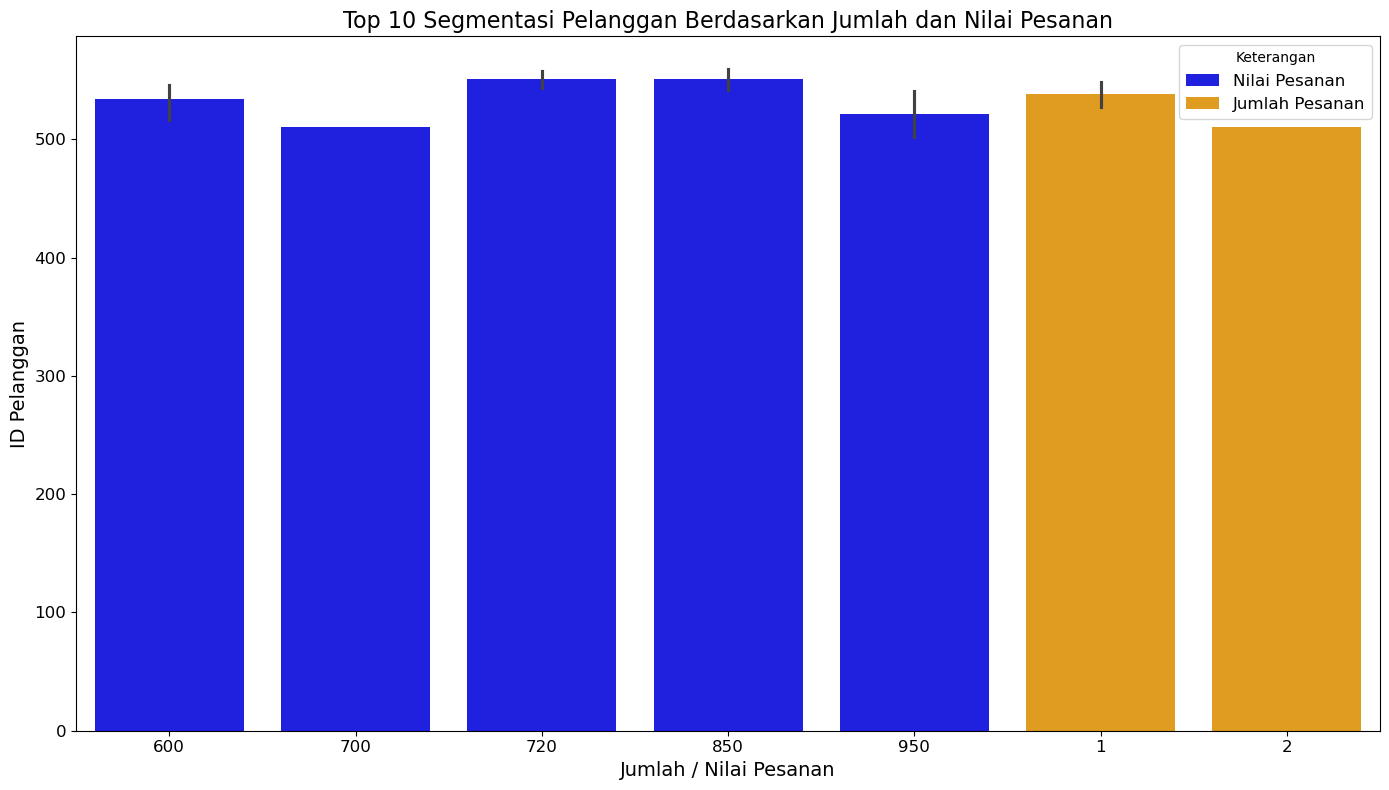

In [116]:
import matplotlib.pyplot as plt
import seaborn as sns

customer_segment = my_data.groupby('customer_id')[['total_sales', 'quantity']].sum().reset_index()
top_customer_segment = customer_segment.sort_values(by='total_sales', ascending=False).head(10)

plt.figure(figsize=(14, 8))
sns.barplot(data=top_customer_segment, x='total_sales', y='customer_id', color='blue', label='Nilai Pesanan')
sns.barplot(data=top_customer_segment, x='quantity', y='customer_id', color='orange', label='Jumlah Pesanan')

plt.title('Top 10 Segmentasi Pelanggan Berdasarkan Jumlah dan Nilai Pesanan', fontsize=16)
plt.xlabel('Jumlah / Nilai Pesanan', fontsize=14)
plt.ylabel('ID Pelanggan', fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.legend(title='Keterangan', fontsize=12)

plt.tight_layout()
plt.show()

AttributeError: module 'matplotlib.pyplot' has no attribute 'tight'

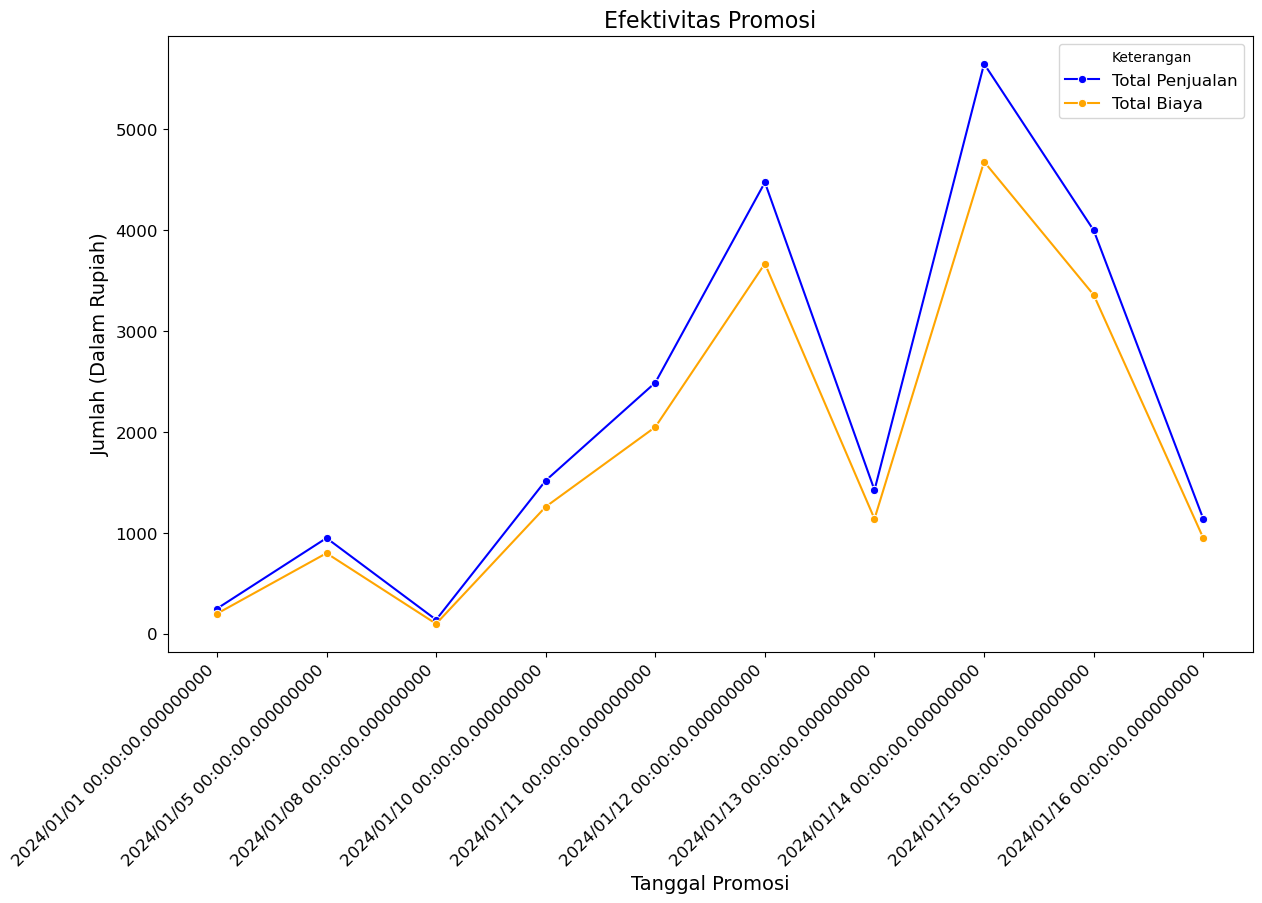

In [118]:
import matplotlib.pyplot as plt
import seaborn as sns

promotion_data = my_data.groupby('promotion_date_1')[['total_sales', 'total_cost']].sum().reset_index()

plt.figure(figsize=(14, 8))
sns.lineplot(data=promotion_data, x='promotion_date_1', y='total_sales', marker='o', label='Total Penjualan', color='blue')
sns.lineplot(data=promotion_data, x='promotion_date_1', y='total_cost', marker='o', label='Total Biaya', color='orange')

plt.title('Efektivitas Promosi', fontsize=16)
plt.xlabel('Tanggal Promosi', fontsize=14)
plt.ylabel('Jumlah (Dalam Rupiah)', fontsize=14)
plt.xticks(rotation=45, ha='right', fontsize=12)
plt.yticks(fontsize=12)
plt.legend(title='Keterangan', fontsize=12)

plt.tight

C:\Users\wince\AppData\Local\Temp\ipykernel_19608\571775648.py:8: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




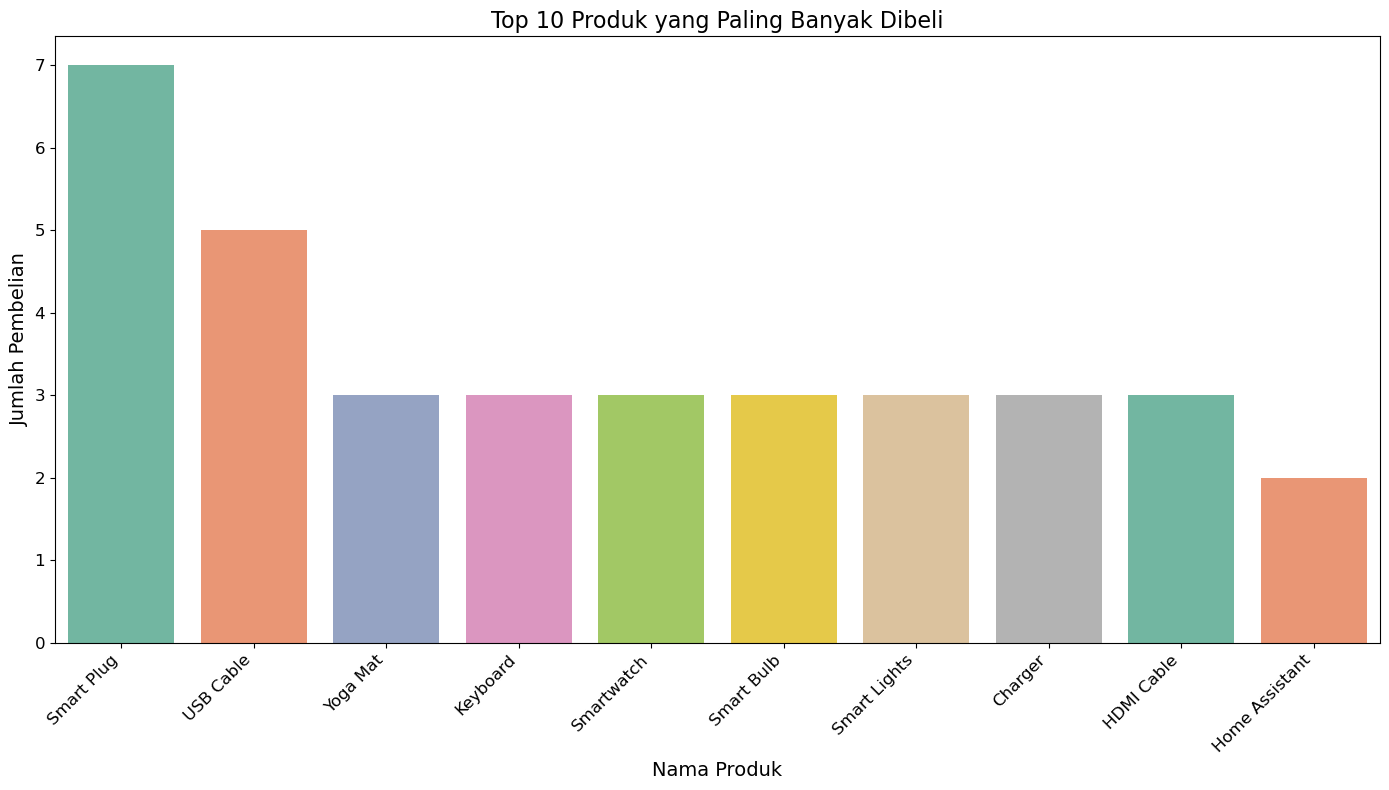

In [120]:
import matplotlib.pyplot as plt
import seaborn as sns

top_products = my_data.groupby('product_name')['quantity'].sum().reset_index()
top_products = top_products.sort_values(by='quantity', ascending=False).head(10)

plt.figure(figsize=(14, 8))
sns.barplot(data=top_products, x='product_name', y='quantity', palette='Set2')

plt.title('Top 10 Produk yang Paling Banyak Dibeli', fontsize=16)
plt.xlabel('Nama Produk', fontsize=14)
plt.ylabel('Jumlah Pembelian', fontsize=14)
plt.xticks(rotation=45, ha='right', fontsize=12)
plt.yticks(fontsize=12)

plt.tight_layout()
plt.show()

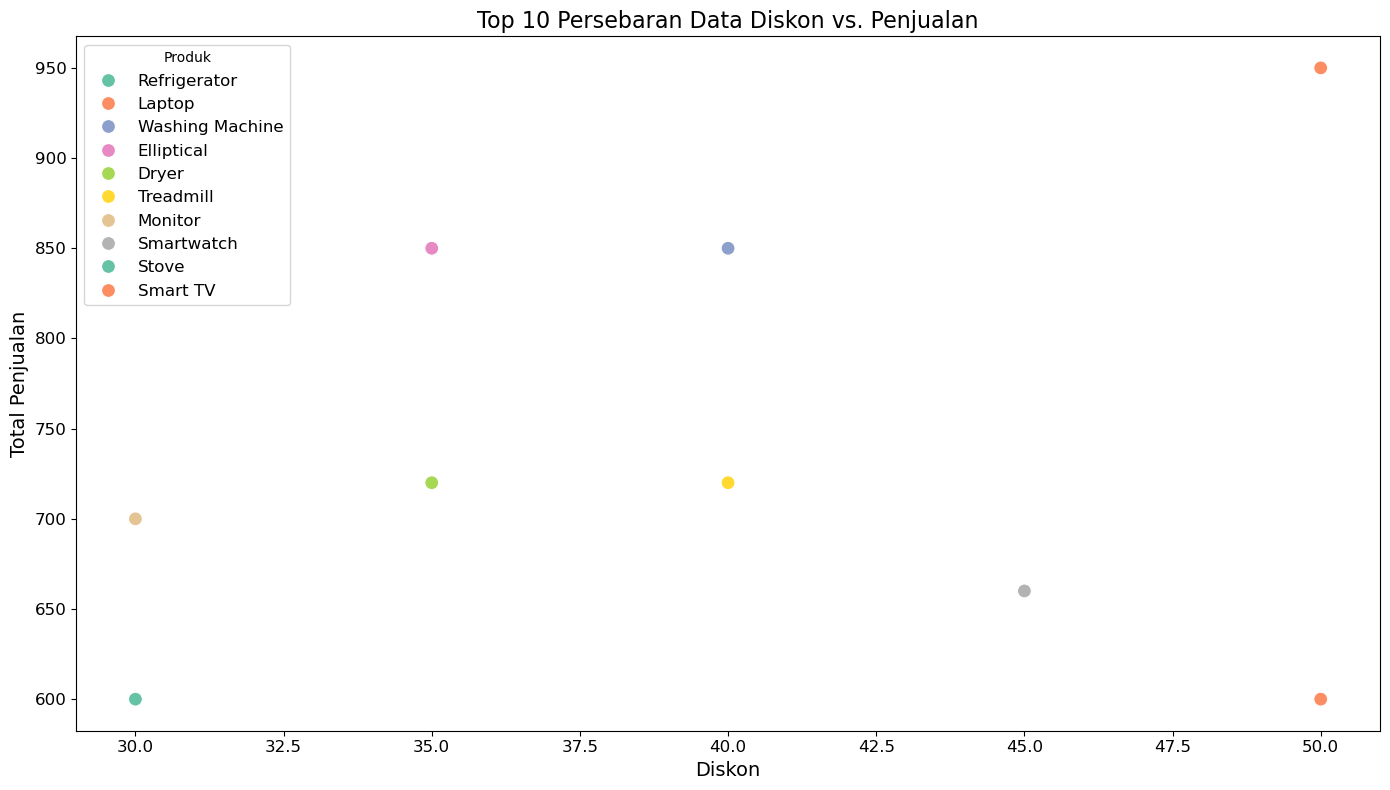

In [122]:
import matplotlib.pyplot as plt
import seaborn as sns

discount_vs_sales = my_data.groupby('product_name')[['discount', 'total_sales']].sum().reset_index()
top_discount_vs_sales = discount_vs_sales.sort_values(by='total_sales', ascending=False).head(10)

plt.figure(figsize=(14, 8))
sns.scatterplot(data=top_discount_vs_sales, x='discount', y='total_sales', hue='product_name', palette='Set2', marker='o', s=100)

plt.title('Top 10 Persebaran Data Diskon vs. Penjualan', fontsize=16)
plt.xlabel('Diskon', fontsize=14)
plt.ylabel('Total Penjualan', fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.legend(title='Produk', fontsize=12)

plt.tight_layout()
plt.show()

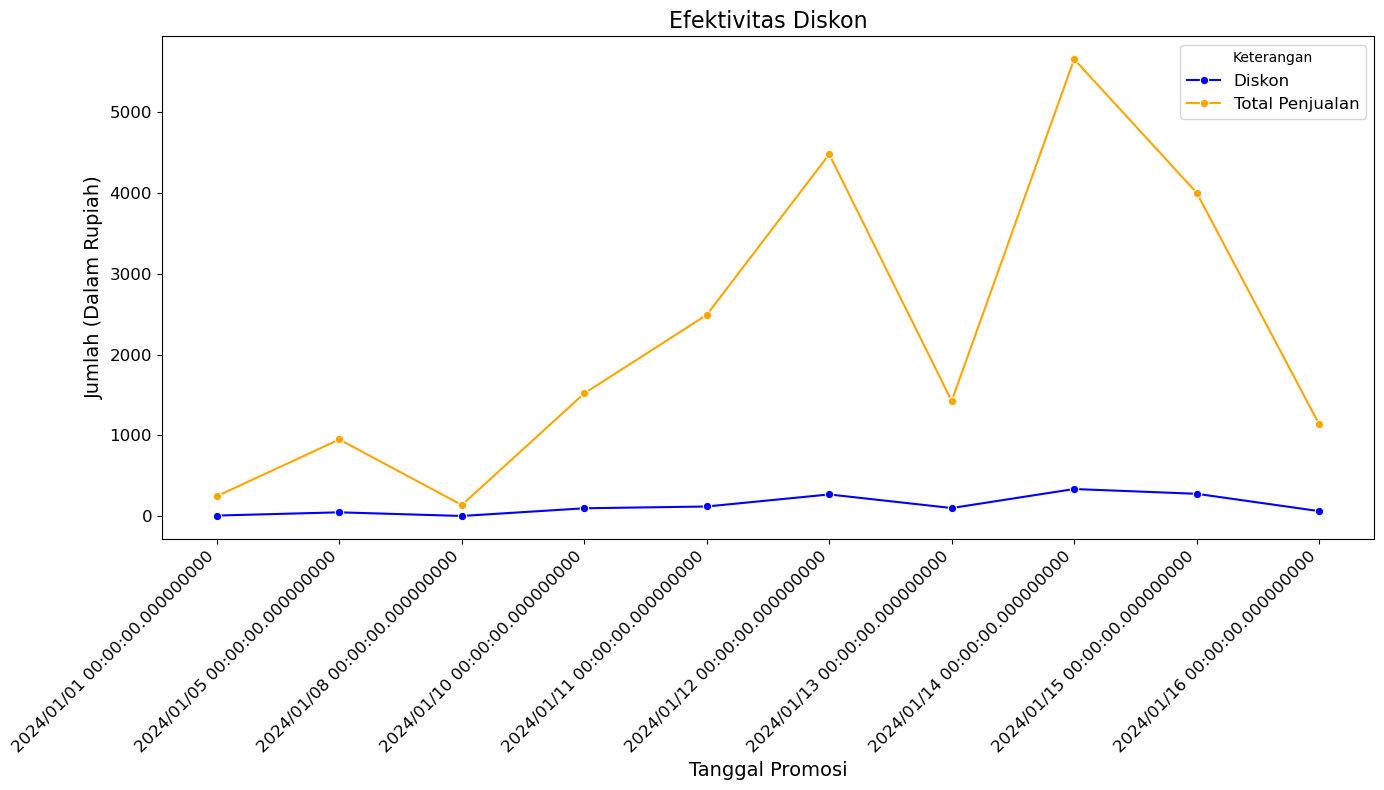

In [124]:
import matplotlib.pyplot as plt
import seaborn as sns

discount_vs_sales = my_data.groupby('promotion_date_1')[['discount', 'total_sales']].sum().reset_index()

plt.figure(figsize=(14, 8))
sns.lineplot(data=discount_vs_sales, x='promotion_date_1', y='discount', marker='o', label='Diskon', color='blue')
sns.lineplot(data=discount_vs_sales, x='promotion_date_1', y='total_sales', marker='o', label='Total Penjualan', color='orange')

plt.title('Efektivitas Diskon', fontsize=16)
plt.xlabel('Tanggal Promosi', fontsize=14)
plt.ylabel('Jumlah (Dalam Rupiah)', fontsize=14)
plt.xticks(rotation=45, ha='right', fontsize=12)
plt.yticks(fontsize=12)
plt.legend(title='Keterangan', fontsize=12)

plt.tight_layout()
plt.show()

----

----

## <div align="center"> Reference </div>

### Input Your Reference Here  (Jika ada):

----